In [4]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [2]:
!pip install catboost


  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 4.2 MB/s eta 0:00:24
    --------------------------------------- 1.6/100.2 MB 4.0 MB/s eta 0:00:25
    --------------------------------------- 2.4/100.2 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 3.1/100.2 MB 4.0 MB/s eta 0:00:25
   - -------------------------------------- 3.9/100.2 MB 4.0 MB/s eta 0:00:25
   - -------------------------------------- 5.0/100.2 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 5.8/100.2 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.8/100.2 MB 4.1 MB/s eta 0:00:23
   --- ------------------------------------ 7.6/100.2 MB 4.1 MB/s eta 0:00:23
   --- ------------------------------------ 8.4/100.2 MB 4.1 MB/s eta 0:00:23
   --- ------------------------------------ 9.4/100.2 MB 4.1 MB/s eta 0:00:22
   ---- 

In [3]:
!pip install xgboost

In [5]:
df = pd.read_csv('data/stud.csv')

In [6]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
X = df.drop(columns=['math_score'],axis=1)
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [8]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [9]:
y = df['math_score']

In [11]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder',OneHotEncoder(),cat_features),
        ('StandardScaler',StandardScaler(),num_features)
    ]
)

In [12]:
X = preprocessor.fit_transform(X)
X.shape

(1000, 19)

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [14]:
def evaluate_model(true,pred):
    mae = mean_absolute_error(true,pred)
    mse = mean_squared_error(true,pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true,pred)
    return mae,mse,rmse,r2

In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae,train_mse,train_rmse,train_r2 = evaluate_model(y_train,y_train_pred)
    test_mae,test_mse,test_rmse,test_r2 = evaluate_model(y_test,y_test_pred)
    print(f"Model: {list(models.keys())[i]}")
    model_list.append(list(models.keys())[i])

    print('Model performance on Training set')
    print(f'MAE: {train_mae}')
    print(f'MSE: {train_mse}')
    print(f'RMSE: {train_rmse}')
    print(f'R2 Score: {train_r2}')

    print('\n')
    print('Model performance on Test set')
    print(f'MAE: {test_mae}')
    print(f'MSE: {test_mse}')
    print(f'RMSE: {test_rmse}')
    print(f'R2 Score: {test_r2}')
    r2_list.append(test_r2)

    print('---------------------------------------------')
    print('\n')



Model: Linear Regression
Model performance on Training set
MAE: 4.266711846071957
MSE: 28.334870380648585
RMSE: 5.323050852720513
R2 Score: 0.8743172040139593


Model performance on Test set
MAE: 4.21476314247485
MSE: 29.095169866715484
RMSE: 5.393993869732842
R2 Score: 0.8804332983749565
---------------------------------------------


Model: Lasso
Model performance on Training set
MAE: 5.206302661246526
MSE: 43.47840400585577
RMSE: 6.593815587795565
R2 Score: 0.8071462015863458


Model performance on Test set
MAE: 5.157881810347763
MSE: 42.5064168384116
RMSE: 6.519694535667419
R2 Score: 0.8253197323627853
---------------------------------------------


Model: Ridge
Model performance on Training set
MAE: 4.264987823725981
MSE: 28.33778823308244
RMSE: 5.323324922741654
R2 Score: 0.8743042615212909


Model performance on Test set
MAE: 4.21110068801426
MSE: 29.056272192348285
RMSE: 5.390387016935638
R2 Score: 0.8805931485028738
---------------------------------------------


Model: K-Neig

In [18]:
list(models.keys())[0]

'Linear Regression'

In [28]:
pd.DataFrame(list(zip(model_list,r2_list)),
             columns=['Model Name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.851622
8,AdaBoost Regressor,0.845840
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783497
4,Decision Tree,0.735738


In [29]:
lin = LinearRegression(fit_intercept=True)
lin_model = lin.fit(X_train,y_train)

y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred)*100
print(f"R2 Score of Linear Regression model is: {score}")


R2 Score of Linear Regression model is: 88.04332983749565


Text(0, 0.5, 'Predicted Values')

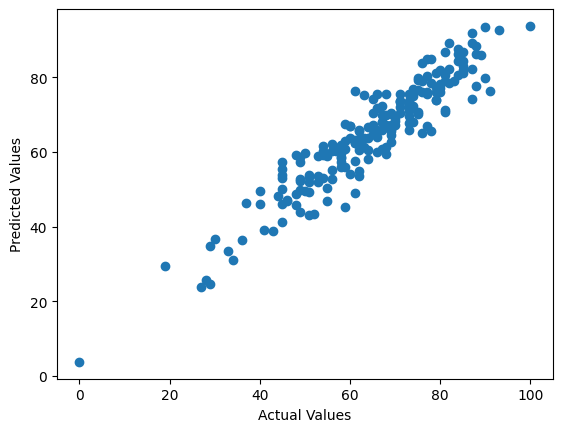

In [30]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

<Axes: xlabel='math_score'>

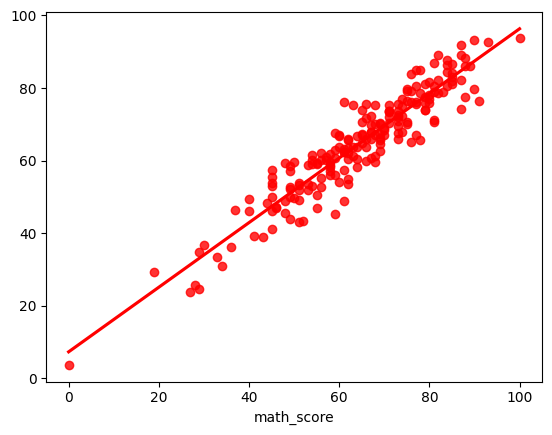

In [31]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

In [32]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
